# VBZ Public Transport Flows – Rush Hour Aggregates

This notebook:

- Loads VBZ public transport flows from a GeoParquet/Parquet file.
- Inspects the schema (columns, dtypes, geometry/CRS).
- Prepares for later aggregation into:
  - Morning rush (06–10)
  - Midday / afternoon (11–15)
  - Evening rush (16–20)
- Eventually: creates 3 side-by-side maps with OSM basemap, one for each period.

> First step: **load and inspect the data**.


In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Path to VBZ hourly flows (public transport)
VBZ_GEO_PARQUET_PATH = (
    "/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/"
    "AWS/containers/local_bucket/gold/vbz_flows/V2_vbz_flows_hourly.parquet"
)

VBZ_GEO_PARQUET_PATH


'/Users/fadricampell/Documents/HSLU/Modules/DWDL/DWDL/AWS/containers/local_bucket/gold/vbz_flows/V2_vbz_flows_hourly.parquet'

In [4]:

vbz_gdf = gpd.read_parquet(VBZ_GEO_PARQUET_PATH)
print("Loaded as GeoDataFrame ✔")
print(f"Type: {type(vbz_gdf)}")
print(f"CRS: {vbz_gdf.crs}")


Loaded as GeoDataFrame ✔
Type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "CH1903+ / LV95", "base_crs": {"name": "CH1903+", "datum": {"type": "GeodeticReferenceFrame", "name": "CH1903+", "ellipsoid": {"name": "Bessel 1841", "semi_major_axis": 6377397.155, "inverse_flattening": 299.1528128}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4150}}, "conversion": {"name": "Swiss Oblique Mercator 1995", "method": {"name": "Hotine Oblique Mercator (variant B)", "id": {"authority": "EPSG", "code": 9815}}, "parameters": [{"name": "Latitude of projection centre", "value": 46.9524055555556, "unit": "degree", "id": {"authority": "EPSG", "code": 8811}}, {"name":

In [5]:

print("=== GeoDataFrame – head ===")
display(vbz_gdf.head())

print("\n=== GeoDataFrame – dtypes ===")
display(vbz_gdf.dtypes)

print("\nColumns:")
print(list(vbz_gdf.columns))

print("Hours column")
print(vbz_gdf.hour)


=== GeoDataFrame – head ===


,Haltestellen_Id,Nach_Hst_Id,hour,flow_besetzung,n_runs,geometry
0,4,5,5.0,3.12963,2,"LINESTRING (2688228.935 1242680.643, 2688077.7..."
1,4,5,6.0,33.13153,8,"LINESTRING (2688228.935 1242680.643, 2688077.7..."
2,4,5,7.0,90.60887,8,"LINESTRING (2688228.935 1242680.643, 2688077.7..."
3,4,5,8.0,31.19336,4,"LINESTRING (2688228.935 1242680.643, 2688077.7..."
4,4,5,9.0,24.66769,4,"LINESTRING (2688228.935 1242680.643, 2688077.7..."



=== GeoDataFrame – dtypes ===


Haltestellen_Id      object
Nach_Hst_Id          object
hour                float64
flow_besetzung      float64
n_runs                int64
geometry           geometry
dtype: object


Columns:
['Haltestellen_Id', 'Nach_Hst_Id', 'hour', 'flow_besetzung', 'n_runs', 'geometry']
Hours column
0         5.0
1         6.0
2         7.0
3         8.0
4         9.0
         ... 
27126    19.0
27127    20.0
27128    21.0
27129    22.0
27130    23.0
Name: hour, Length: 27131, dtype: float64


In [6]:
# Work on a copy
vbz = vbz_gdf.copy()

# Convert hour to integer
vbz["hour"] = vbz["hour"].astype(int)

# Create a unique EDGE ID for the "from–to" stop pair
vbz["edge_id"] = vbz["Haltestellen_Id"].astype(str) + "_" + vbz["Nach_Hst_Id"].astype(str)

# Show confirmation
vbz[["Haltestellen_Id", "Nach_Hst_Id", "edge_id", "hour", "flow_besetzung"]].head()


,Haltestellen_Id,Nach_Hst_Id,edge_id,hour,flow_besetzung
0,4,5,4_5,5,3.12963
1,4,5,4_5,6,33.13153
2,4,5,4_5,7,90.60887
3,4,5,4_5,8,31.19336
4,4,5,4_5,9,24.66769


In [7]:
# Time windows for public transport flows
MORNING_HOURS = list(range(6, 11))   # 06–10
MIDDAY_HOURS  = list(range(11, 16))  # 11–15
EVENING_HOURS = list(range(16, 21))  # 16–20

HOUR_COL = "hour"
FLOW_COL = "flow_besetzung"
EDGE_ID_COL = "edge_id"

AGG_FUNC = "sum"   # can switch to 'mean'


In [8]:
def aggregate_for_hours(gdf, hours, hour_col, flow_col, edge_id_col, agg_func="sum"):
    subset = gdf[gdf[hour_col].isin(hours)].copy()
    if subset.empty:
        raise ValueError(f"No rows found for hours {hours}")

    # Aggregate flow
    aggregated = (
        subset.groupby(edge_id_col)
        .agg({
            flow_col: agg_func,
            "geometry": "first"   # geometry identical for same edge
        })
        .reset_index()
    )

    return gpd.GeoDataFrame(aggregated, geometry="geometry", crs=gdf.crs)


In [9]:
gdf_morning = aggregate_for_hours(
    vbz, MORNING_HOURS, HOUR_COL, FLOW_COL, EDGE_ID_COL, AGG_FUNC
)

gdf_midday = aggregate_for_hours(
    vbz, MIDDAY_HOURS, HOUR_COL, FLOW_COL, EDGE_ID_COL, AGG_FUNC
)

gdf_evening = aggregate_for_hours(
    vbz, EVENING_HOURS, HOUR_COL, FLOW_COL, EDGE_ID_COL, AGG_FUNC
)

print("Morning:", len(gdf_morning))
print("Midday:", len(gdf_midday))
print("Evening:", len(gdf_evening))


Morning: 1474
Midday: 1469
Evening: 1469


In [10]:
flows_3 = pd.concat([
    gdf_morning[FLOW_COL],
    gdf_midday[FLOW_COL],
    gdf_evening[FLOW_COL],
])

max_flow_3 = flows_3.max()
min_flow_3 = flows_3.min()

print(f"Flow range (3 VBZ periods): {min_flow_3:.2f} – {max_flow_3:.2f}")

from matplotlib.colors import Normalize
norm_3 = Normalize(vmin=0, vmax=max_flow_3)
cmap_3 = plt.cm.plasma   # PT flows look a bit better in plasma or viridis

# Line width parameters
BASE_LW_3 = 0.3
MAX_EXTRA_LW_3 = 3.5


Flow range (3 VBZ periods): 0.69 – 13453.68


In [11]:
import contextily as ctx

gdf_morning_3857 = gdf_morning.to_crs(epsg=3857)
gdf_midday_3857  = gdf_midday.to_crs(epsg=3857)
gdf_evening_3857 = gdf_evening.to_crs(epsg=3857)


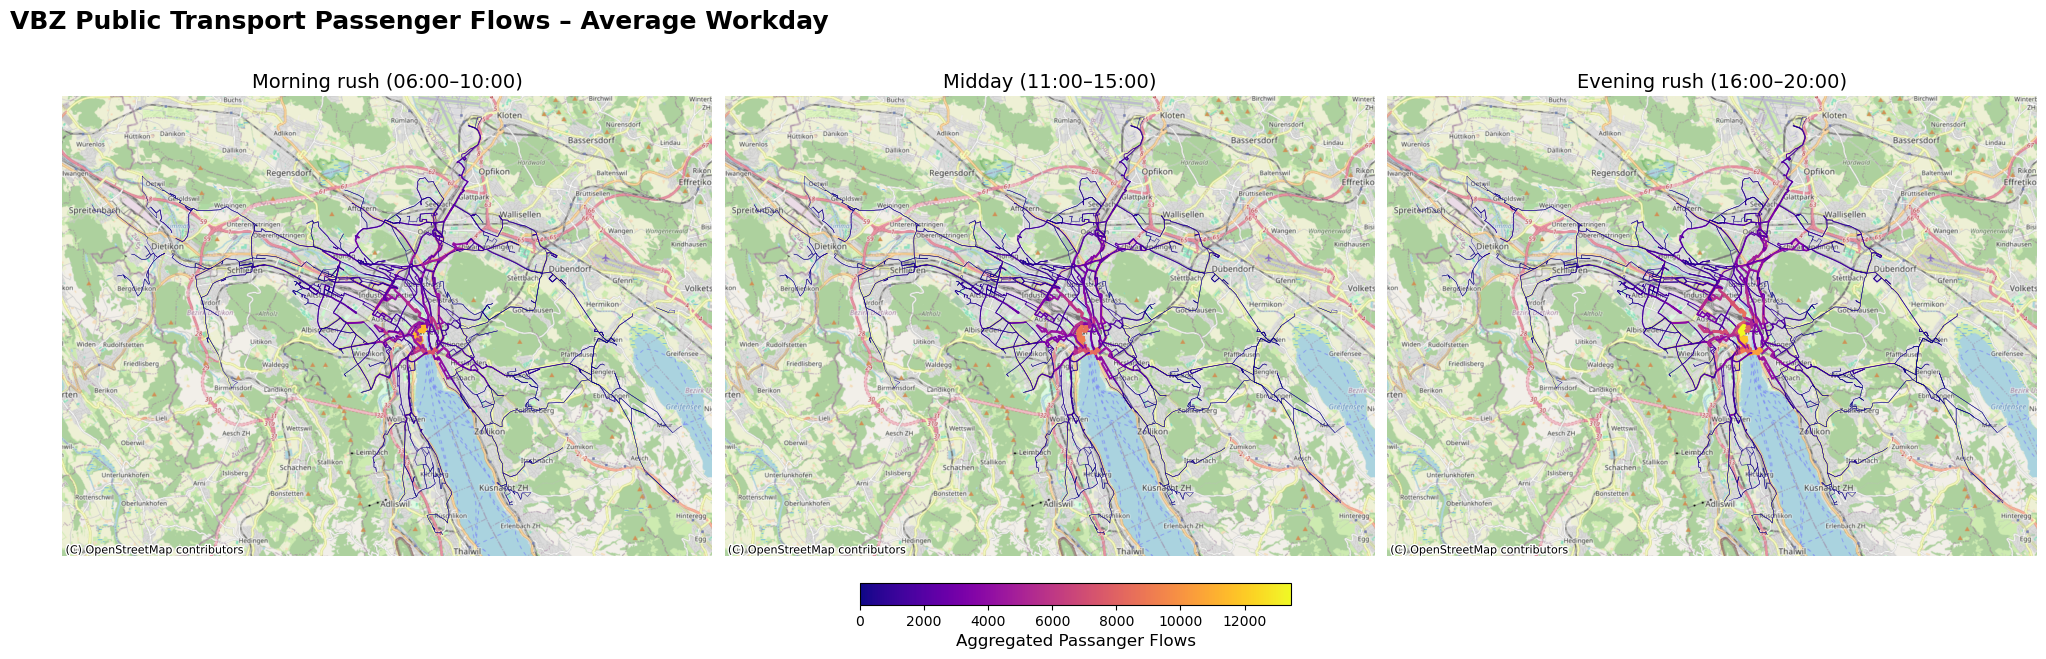

In [12]:
import matplotlib as mpl

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

periods_vbz = [
    ("Morning rush (06:00–10:00)", gdf_morning_3857),
    ("Midday (11:00–15:00)", gdf_midday_3857),
    ("Evening rush (16:00–20:00)", gdf_evening_3857),
]

for ax, (title, gdf_agg) in zip(axes.flat, periods_vbz):

    lw = BASE_LW_3 + MAX_EXTRA_LW_3 * (gdf_agg[FLOW_COL] / max_flow_3)
    colors = cmap_3(norm_3(gdf_agg[FLOW_COL].values))

    gdf_agg.plot(
        ax=ax,
        color=colors,
        linewidth=lw,
        zorder=2,
    )

    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        crs=gdf_agg.crs,
        zorder=1,
    )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect("equal")

# Colorbar for VBZ flows
sm = mpl.cm.ScalarMappable(norm=norm_3, cmap=cmap_3)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.04,
    pad=0.10,
)
cbar.set_label("Aggregated Passanger Flows", fontsize=12)

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.90,
    bottom=0.18,
    wspace=0.02,
)

plt.suptitle(
    "VBZ Public Transport Passenger Flows – Average Workday",
    fontsize=18,
    fontweight="bold",
    y=0.96,
    x=0.2
)

plt.show()
